In [1]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END

from state import TriageState, TriageResult, ValidationResult

from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL")

model = ChatGroq(
    model=GROQ_MODEL,
    api_key=GROQ_API_KEY,
    temperature=0,
)

structured_model = model.with_structured_output(
    TriageResult
)

In [3]:
def classify_with_llm(state: TriageState):
    email = state.get("email", "").strip()

    if not email:
        raise ValueError("Email cannot be empty")

    prompt = f"""
You are an email triage assistant.

Classify the email using the required structured schema.

Classification rules:
- Complaint: A customer reports a problem or dissatisfaction.
- Feedback: A customer provides an opinion or suggestion.
- Request: A customer asks for information or an action.
- Spam: Unwanted, deceptive, or irrelevant messages.
- Other: Does not fit the categories above.

Priority rules:
- Low: No urgency and no significant impact.
- Medium: Requires attention but is not urgent.
- High: Significant issue or time-sensitive request.
- Critical: Severe impact, security concern, or immediate risk.

Additional rules:
- Use only information present in the email.
- Do not invent facts.
- Write a concise summary.
- Set confidence between 0 and 1.
- Consider whether human review is required.

Email:
<email_content>
{email}
</email_content>
"""

    result = structured_model.invoke(prompt)

    return {
        "triage_result": result
    }

In [14]:

def validate_triage(state: TriageState):
    triage_result = state.get("triage_result")

    errors = []

    # Case 1: Classification result is missing
    if triage_result is None:
        errors.append("Triage result is missing.")

        validation_result = ValidationResult(
            passed=False,
            errors=errors,
            review_reason="Classification result is missing.",
            route="human_review",
        )

        return {
            "validation_result": validation_result
        }

    # Case 2: Confidence is too low
    if triage_result.confidence < 0.70:
        errors.append(
            "Classification confidence is below 0.70."
        )

    # Case 3: Critical priority requires review
    if triage_result.priority == "Critical":
        errors.append(
            "Critical-priority email requires human review."
        )

    # Case 4: High priority requires review
    if triage_result.priority == "High":
        errors.append(
            "High-priority email requires human review."
        )

    # Case 5: Model itself recommends human review
    if triage_result.needs_human_review:
        errors.append(
            "The model recommended human review."
        )

    # Decide the final route
    if len(errors) == 0:
        validation_result = ValidationResult(
            passed=True,
            errors=[],
            review_reason="",
            route="automatic_processing",
        )
    else:
        validation_result = ValidationResult(
            passed=False,
            errors=errors,
            review_reason=" ".join(errors),
            route="human_review",
        )

    return {
        "validation_result": validation_result
    }

In [15]:
def route_email(state: TriageState):
    validation_result = state.get("validation_result")

    if validation_result is None:
        return "human_review"

    return validation_result.route

In [16]:
def human_review(state: TriageState):
    triage_result = state.get("triage_result")
    validation_result = state.get("validation_result")

    print("\n--- HUMAN REVIEW REQUIRED ---")

    if triage_result:
        print("Category:", triage_result.category)
        print("Priority:", triage_result.priority)
        print("Summary:", triage_result.summary)

    if validation_result:
        print("Validation Errors:", validation_result.errors)
        print("Review Reason:", validation_result.review_reason)

    return {}

In [17]:
def automatic_processing(state: TriageState):
    triage_result = state.get("triage_result")

    print("\n--- AUTOMATIC PROCESSING ---")

    if triage_result:
        print("Category:", triage_result.category)
        print("Priority:", triage_result.priority)
        print("Summary:", triage_result.summary)

    return {}

In [18]:
builder = StateGraph(TriageState)

# 1. Classification
builder.add_node("classify_with_llm",classify_with_llm)

# 2. Deterministic validation
builder.add_node("validate_triage",validate_triage)

# 3. Destination nodes
builder.add_node("human_review",human_review)
builder.add_node("automatic_processing",automatic_processing)

# 4. Normal edge: classification → validation
builder.add_edge(START,"classify_with_llm")
builder.add_edge("classify_with_llm","validate_triage")

# 5. Conditional edge: validation → selected route
builder.add_conditional_edges("validate_triage",route_email,
    {
        "human_review": "human_review",
        "automatic_processing": "automatic_processing",
    },
)

# 6. Both paths finish the workflow
builder.add_edge("human_review",END)
builder.add_edge("automatic_processing",END)

graph = builder.compile()



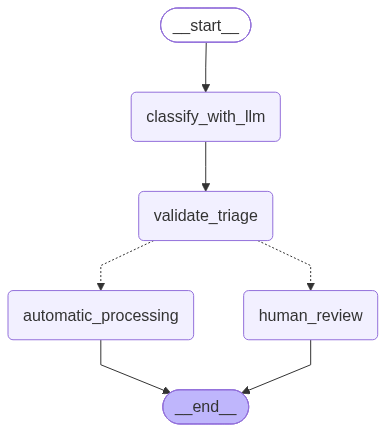

In [19]:
from IPython.display import display, Image


Image(graph.get_graph().draw_mermaid_png())



In [20]:
try:
    result = graph.invoke({
        "email": """
        Subject: Product suggestion

        I really like your application.
        It would be helpful if you added a dark mode.
        """
    })

    print("Graph executed successfully:")
    print(result)

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR MESSAGE:", str(e))


--- AUTOMATIC PROCESSING ---
Category: Feedback
Priority: Low
Summary: Customer expresses satisfaction with the application and suggests adding a dark mode feature.
Graph executed successfully:
{'email': '\n        Subject: Product suggestion\n\n        I really like your application.\n        It would be helpful if you added a dark mode.\n        ', 'triage_result': TriageResult(category='Feedback', priority='Low', summary='Customer expresses satisfaction with the application and suggests adding a dark mode feature.', confidence=0.95, needs_human_review=False), 'validation_result': ValidationResult(passed=True, errors=[], review_reason='', route='automatic_processing')}


In [21]:
test_emails = [
    {
        "name": "Feedback",
        "email": """
        Subject: Product suggestion

        I really like your application.
        It would be helpful if you added a dark mode.
        """
    },
    {
        "name": "Complaint",
        "email": """
        Subject: Payment issue

        I was charged twice for my subscription.
        Please resolve this issue as soon as possible.
        """
    },
    {
        "name": "Critical security issue",
        "email": """
        Subject: URGENT SECURITY BREACH

        Someone has gained unauthorized access to my account.
        My personal data may be exposed.
        Please take immediate action.
        """
    },
    {
        "name": "General request",
        "email": """
        Subject: Refund policy

        Could you please explain your refund policy?
        """
    },
]

In [22]:
for test in test_emails:
    print("\n" + "=" * 60)
    print("TEST:", test["name"])
    print("=" * 60)

    try:
        result = graph.invoke({
            "email": test["email"]
        })

        triage = result.get("triage_result")
        validation = result.get("validation_result")

        print("\nClassification:")

        if triage:
            print("Category:", triage.category)
            print("Priority:", triage.priority)
            print("Summary:", triage.summary)
            print("Confidence:", triage.confidence)
            print(
                "Model requests review:",
                triage.needs_human_review
            )

        print("\nValidation:")

        if validation:
            print("Passed:", validation.passed)
            print("Route:", validation.route)
            print("Errors:", validation.errors)

    except Exception as e:
        print("ERROR TYPE:", type(e).__name__)
        print("ERROR MESSAGE:", str(e))


TEST: Feedback

--- AUTOMATIC PROCESSING ---
Category: Feedback
Priority: Low
Summary: Customer expresses satisfaction with the application and suggests adding a dark mode feature.

Classification:
Category: Feedback
Priority: Low
Summary: Customer expresses satisfaction with the application and suggests adding a dark mode feature.
Confidence: 0.95
Model requests review: False

Validation:
Passed: True
Route: automatic_processing
Errors: []

TEST: Complaint

--- HUMAN REVIEW REQUIRED ---
Category: Complaint
Priority: High
Summary: Customer reports being charged twice for their subscription and requests immediate resolution.
Validation Errors: ['High-priority email requires human review.']
Review Reason: High-priority email requires human review.

Classification:
Category: Complaint
Priority: High
Summary: Customer reports being charged twice for their subscription and requests immediate resolution.
Confidence: 0.95
Model requests review: False

Validation:
Passed: False
Route: human_r